# Предсказание RON и MON по SMILES: RDKit-дескрипторы и классическое ML

В этом ноутбуке мы:
- загружаем табличные данные по топливам и целевые величины **RON** и **MON**;
- строим признаки **только средствами RDKit** (2D-дескрипторы и отпечатки);
- отбираем признаки и оцениваем их важность;
- подбираем гиперпараметры через **Optuna**;
- обучаем и сравниваем **классические** регрессоры и **градиентные бустинги** (XGBoost, LightGBM, CatBoost при установленных пакетах);
- строим **ансамбль** из нескольких сильных моделей;
- для лучшей модели по каждому таргету визуализируем **predicted vs true** и **остатки vs предсказание**.


## 1. Импорты и настройки

In [9]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    VotingRegressor,
    StackingRegressor,
)
from sklearn.linear_model import Ridge
from sklearn.svm import SVR

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor


OPTUNA_MODEL_NAMES = [
    "random_forest",
    "extra_trees",
    "gradient_boosting",
    "ridge",
    "svr",
    "xgboost",
    "lightgbm",
    "catboost",
]
print("Модели для Optuna:", OPTUNA_MODEL_NAMES)

from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, rdMolDescriptors
from rdkit.Chem import rdFingerprintGenerator

warnings.filterwarnings("ignore", category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH = Path("data.csv")
assert DATA_PATH.exists(), f"Положите {DATA_PATH.resolve()} рядом с ноутбуком или поправьте путь."


Модели для Optuna: ['random_forest', 'extra_trees', 'gradient_boosting', 'ridge', 'svr', 'xgboost', 'lightgbm', 'catboost']


## 2. Загрузка и очистка данных

Читаем `data.csv`, оставляем строки с валидными **RON** и **MON**. Идентификаторы и SMILES не входят в матрицу признаков моделей (в признаках только выход RDKit).


In [10]:
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df_clean = df.dropna(subset=["RON", "MON"]).copy()
print("Размер после удаления пропусков по RON/MON:", df_clean.shape)
display(df_clean.head())
df_clean[["RON", "MON"]].describe()


Размер после удаления пропусков по RON/MON: (249, 26)


,Name,FuelClass,Smiles,P,S,T,Q+Qr,P*,S*,T*,...,Br,DD,SCpos,C=O,O,COO,nBP,RON,MON,OS
0,Ethane,Alkanes,CC,2,0,0,0,0,0,0,...,0.0,0,0,0,0,0,0,111.0,100.7,10.3
1,Propane,Alkanes,CCC,2,1,0,0,0,0,0,...,0.0,0,0,0,0,0,0,112.5,97.1,15.4
2,n-Butane,Alkanes,CCCC,2,2,0,0,0,0,0,...,0.0,0,0,0,0,0,0,93.6,90.1,3.5
3,n-Pentane,Alkanes,CCCCC,2,3,0,0,0,0,0,...,0.0,0,0,0,0,0,0,61.7,61.9,-0.2
4,n-Hexane,Alkanes,CCCCCC,2,4,0,0,0,0,0,...,0.0,0,0,0,0,0,0,24.8,26.0,-1.2


,RON,MON
count,249.000000,249.000000
mean,91.093574,82.489960
std,21.625814,18.627335
min,0.000000,0.000000
25%,83.100000,74.600000
50%,97.000000,84.600000
75%,105.000000,93.500000
max,120.300000,120.300000


## 3. Дескрипторы и отпечатки только через RDKit

Для каждого SMILES:
- молекула `Chem.MolFromSmiles`;
- набор числовых **2D-дескрипторов** из модуля `Descriptors` / `rdMolDescriptors` (только то, что даёт RDKit);
- **Morgan fingerprint** (битовый вектор через генератор отпечатков RDKit);
- **MACCS keys** (`GetMACCSKeysFingerprint`).

Строки с невалидным SMILES отбрасываются.


In [11]:
DESC_NAMES = [
    "MolWt", "MolLogP", "TPSA", "NumHAcceptors", "NumHDonors", "NumRotatableBonds",
    "NumAromaticRings", "NumAliphaticRings", "RingCount", "FractionCSP3", "HeavyAtomCount",
    "NumRadicalElectrons", "NumValenceElectrons", "NumSaturatedRings", "NumAliphaticCarbocycles",
    "NumAromaticCarbocycles", "NumSaturatedHeterocycles", "NumAromaticHeterocycles",
    "NumAliphaticHeterocycles", "NumSaturatedCarbocycles", "NumHeteroatoms", "NumAromaticAtoms",
    "Chi0", "Chi1", "Kappa1", "Kappa2", "Kappa3", "LabuteASA", "PEOE_VSA1", "NHOHCount", "NOCount",
]
DESC_NAMES = [n for n in DESC_NAMES if hasattr(Descriptors, n)]


def compute_rdkit_2d_descriptors(smiles_list: list[str]) -> pd.DataFrame:
    funcs = {n: getattr(Descriptors, n) for n in DESC_NAMES}
    records = []
    for s in smiles_list:
        mol = Chem.MolFromSmiles(s)
        row = {}
        for name, fn in funcs.items():
            try:
                row[name] = float(fn(mol)) if mol is not None else np.nan
            except Exception:
                row[name] = np.nan
        records.append(row)
    return pd.DataFrame(records)


def morgan_fingerprints(smiles_list: list[str], radius: int = 2, n_bits: int = 1024) -> pd.DataFrame:
    gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    rows = []
    for s in smiles_list:
        mol = Chem.MolFromSmiles(s)
        if mol is None:
            rows.append(np.zeros(n_bits, dtype=np.float32))
        else:
            rows.append(gen.GetFingerprintAsNumPy(mol).astype(np.float32))
    cols = [f"morgan_{i}" for i in range(n_bits)]
    return pd.DataFrame(rows, columns=cols)


def maccs_fingerprints(smiles_list: list[str]) -> pd.DataFrame:
    fps = []
    for s in smiles_list:
        mol = Chem.MolFromSmiles(s)
        arr = np.zeros(167, dtype=np.float32)
        if mol is not None:
            fp = rdMolDescriptors.GetMACCSKeysFingerprint(mol)
            DataStructs.ConvertToNumpyArray(fp, arr)
        fps.append(arr)
    cols = [f"maccs_{i}" for i in range(167)]
    return pd.DataFrame(fps, columns=cols)


smiles = df_clean["Smiles"].astype(str).tolist()
valid_mask = np.array([Chem.MolFromSmiles(s) is not None for s in smiles], dtype=bool)
df_X = df_clean.loc[valid_mask].reset_index(drop=True)
smiles_ok = df_X["Smiles"].astype(str).tolist()

desc_2d = compute_rdkit_2d_descriptors(smiles_ok)
morgan = morgan_fingerprints(smiles_ok, radius=2, n_bits=1024)
maccs = maccs_fingerprints(smiles_ok)

X_raw = pd.concat([desc_2d, morgan, maccs], axis=1)
y_ron = df_X["RON"].values.astype(float)
y_mon = df_X["MON"].values.astype(float)

print("Признаков:", X_raw.shape[1], "объектов:", len(df_X))
X_raw.head()


Признаков: 1221 объектов: 249


,MolWt,MolLogP,TPSA,NumHAcceptors,NumHDonors,NumRotatableBonds,NumAromaticRings,NumAliphaticRings,RingCount,FractionCSP3,...,maccs_157,maccs_158,maccs_159,maccs_160,maccs_161,maccs_162,maccs_163,maccs_164,maccs_165,maccs_166
0,30.070,1.0262,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,44.097,1.4163,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,58.124,1.8064,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,72.151,2.1965,0.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,86.178,2.5866,0.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Разделение на обучение и тест

Фиксируем `random_state` для воспроизводимости. Все дальнейшие шаги (отбор признаков, Optuna) выполняются **только на train**, финальная оценка — на **test**.


In [12]:
X_train, X_test, y_ron_train, y_ron_test, y_mon_train, y_mon_test = train_test_split(
    X_raw, y_ron, y_mon, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (199, 1221) Test: (50, 1221)


## 5. Отбор признаков (train only)

1. **VarianceThreshold** — убираем почти константные признаки.
2. Удаление сильно коррелирующих столбцов (|ρ| > 0.95) по обучающей выборке.
3. **SelectKBest** с `f_regression` — оставляем топ-K признаков; K подбирается Optuna вместе с моделью.


In [13]:
def remove_low_variance(X: pd.DataFrame, threshold: float = 1e-6) -> pd.DataFrame:
    vt = VarianceThreshold(threshold=threshold)
    Xt = vt.fit_transform(X)
    cols = X.columns[vt.get_support(indices=True)]
    return pd.DataFrame(Xt, columns=cols, index=X.index)


def remove_high_correlation(X: pd.DataFrame, thresh: float = 0.95) -> pd.DataFrame:
    corr = X.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop_cols = [c for c in upper.columns if any(upper[c] > thresh)]
    return X.drop(columns=drop_cols)


def preprocess_features(X: pd.DataFrame) -> pd.DataFrame:
    Xv = remove_low_variance(X)
    return remove_high_correlation(Xv, thresh=0.95)


X_train_f = preprocess_features(X_train)
X_test_f = X_test[X_train_f.columns]
print("После variance + correlation:", X_train_f.shape)


После variance + correlation: (199, 400)


## 6. Важность признаков

Обучим **RandomForest** на отфильтрованных признаках с фиксированным **SelectKBest**: сравним ранжирование по F-статистике и по `feature_importances_` леса (иллюстрация для таргета RON).


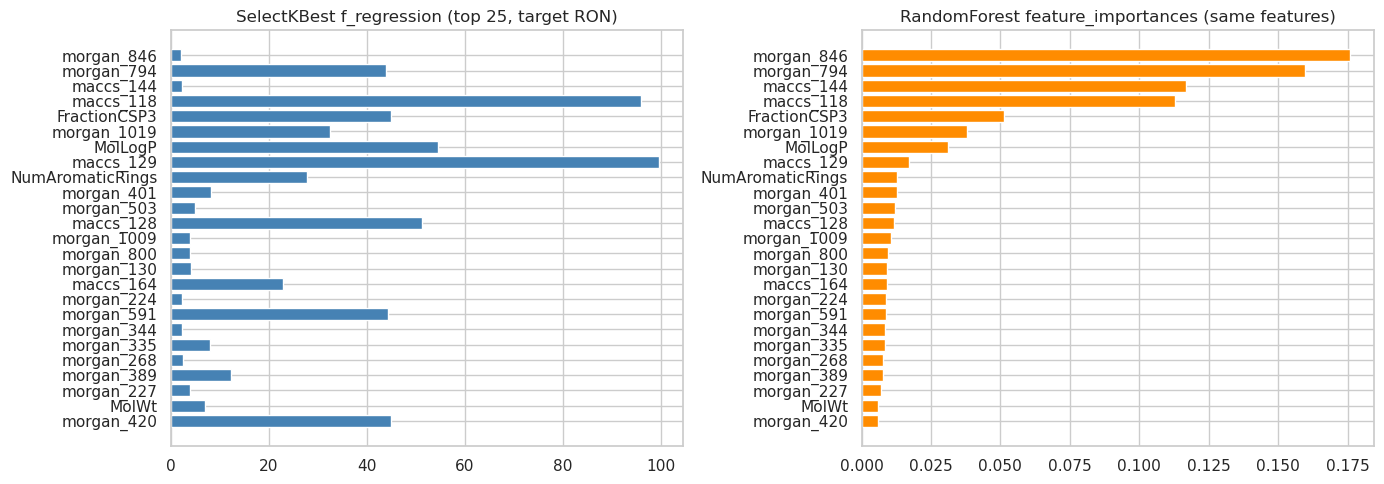

In [14]:
K_VIZ = min(120, X_train_f.shape[1])

selector_viz = SelectKBest(score_func=f_regression, k=K_VIZ)
X_tr_sel = selector_viz.fit_transform(X_train_f, y_ron_train)
mask = selector_viz.get_support()
feat_names = X_train_f.columns[mask].tolist()
scores = selector_viz.scores_[mask]

imp_df = pd.DataFrame({"feature": feat_names, "f_score": scores}).sort_values("f_score", ascending=False)

rf_viz = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf_viz.fit(X_tr_sel, y_ron_train)
imp_df["rf_importance"] = rf_viz.feature_importances_
imp_df = imp_df.sort_values("rf_importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_n = 25
sub = imp_df.head(top_n)
axes[0].barh(sub["feature"][::-1], sub["f_score"][::-1], color="steelblue")
axes[0].set_title(f"SelectKBest f_regression (top {top_n}, target RON)")
axes[1].barh(sub["feature"][::-1], sub["rf_importance"][::-1], color="darkorange")
axes[1].set_title("RandomForest feature_importances (same features)")
plt.tight_layout()
plt.show()


## 7. Optuna: подбор гиперпараметров и K для SelectKBest

Для каждого таргета (**RON** и **MON**) и каждой модели — отдельное исследование Optuna. Минимизируем **MAE** по 5-fold CV на train.

Модели: `RandomForest`, `ExtraTrees`, `GradientBoosting` (sklearn), **`XGBRegressor`**, **`LGBMRegressor`**, **`CatBoostRegressor`**, `Ridge`, `SVR`.


In [15]:
N_TRIALS = 35
CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def build_pipeline_from_trial(model_name: str, trial: optuna.Trial):
    k = trial.suggest_int("k_best", 40, min(400, X_train_f.shape[1]), step=20)
    if model_name == "random_forest":
        est = RandomForestRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 500, step=50),
            max_depth=trial.suggest_int("max_depth", 4, 30),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 5),
            max_features=trial.suggest_categorical("max_features", ["sqrt", 0.3, 0.5, 1.0]),
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        return Pipeline([("select", SelectKBest(score_func=f_regression, k=k)), ("model", est)])
    if model_name == "extra_trees":
        est = ExtraTreesRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 500, step=50),
            max_depth=trial.suggest_int("max_depth", 4, 30),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 5),
            max_features=trial.suggest_categorical("max_features", ["sqrt", 0.3, 0.5, 1.0]),
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        return Pipeline([("select", SelectKBest(score_func=f_regression, k=k)), ("model", est)])
    if model_name == "gradient_boosting":
        est = GradientBoostingRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 400, step=50),
            learning_rate=trial.suggest_float("learning_rate", 0.03, 0.2, log=True),
            max_depth=trial.suggest_int("max_depth", 2, 6),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            random_state=RANDOM_STATE,
        )
        return Pipeline([("select", SelectKBest(score_func=f_regression, k=k)), ("model", est)])
    if model_name == "xgboost":
        est = XGBRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 500, step=50),
            max_depth=trial.suggest_int("max_depth", 3, 12),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            random_state=RANDOM_STATE,
            n_jobs=1,
            verbosity=0,
        )
        return Pipeline([("select", SelectKBest(score_func=f_regression, k=k)), ("model", est)])
    if model_name == "lightgbm":
        est = LGBMRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 500, step=50),
            max_depth=trial.suggest_int("max_depth", 3, 15),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            num_leaves=trial.suggest_int("num_leaves", 16, 256),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            random_state=RANDOM_STATE,
            n_jobs=1,
            verbose=-1,
        )
        return Pipeline([("select", SelectKBest(score_func=f_regression, k=k)), ("model", est)])
    if model_name == "catboost":
        est = CatBoostRegressor(
            iterations=trial.suggest_int("iterations", 100, 500, step=50),
            depth=trial.suggest_int("depth", 4, 10),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 30.0, log=True),
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
            loss_function="RMSE",
            thread_count=4,
        )
        return Pipeline([("select", SelectKBest(score_func=f_regression, k=k)), ("model", est)])
    if model_name == "ridge":
        alpha = trial.suggest_float("alpha", 1e-4, 50.0, log=True)
        est = Ridge(alpha=alpha, random_state=RANDOM_STATE)
        return Pipeline(
            [
                ("select", SelectKBest(score_func=f_regression, k=k)),
                ("scale", StandardScaler()),
                ("model", est),
            ]
        )
    if model_name == "svr":
        C = trial.suggest_float("C", 1e-1, 200.0, log=True)
        gamma = trial.suggest_categorical("gamma", ["scale", "auto"])
        epsilon = trial.suggest_float("epsilon", 1e-3, 1.0, log=True)
        est = SVR(kernel="rbf", C=C, gamma=gamma, epsilon=epsilon)
        return Pipeline(
            [
                ("select", SelectKBest(score_func=f_regression, k=k)),
                ("scale", StandardScaler()),
                ("model", est),
            ]
        )
    raise ValueError(model_name)


def make_objective(model_name: str, y_tr: np.ndarray):
    def objective(trial: optuna.Trial) -> float:
        pipe = build_pipeline_from_trial(model_name, trial)
        scores = cross_val_score(
            pipe, X_train_f, y_tr, cv=CV, scoring="neg_mean_absolute_error", n_jobs=-1
        )
        return float(-scores.mean())

    return objective


def fit_best_pipeline(model_name: str, params: dict, y_tr: np.ndarray) -> Pipeline:
    k = int(params["k_best"])
    bp = {a: b for a, b in params.items() if a != "k_best"}
    if model_name == "random_forest":
        est = RandomForestRegressor(
            n_estimators=bp["n_estimators"],
            max_depth=bp["max_depth"],
            min_samples_leaf=bp["min_samples_leaf"],
            max_features=bp["max_features"],
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        return Pipeline([("select", SelectKBest(score_func=f_regression, k=k)), ("model", est)])
    if model_name == "extra_trees":
        est = ExtraTreesRegressor(
            n_estimators=bp["n_estimators"],
            max_depth=bp["max_depth"],
            min_samples_leaf=bp["min_samples_leaf"],
            max_features=bp["max_features"],
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        return Pipeline([("select", SelectKBest(score_func=f_regression, k=k)), ("model", est)])
    if model_name == "gradient_boosting":
        est = GradientBoostingRegressor(
            n_estimators=bp["n_estimators"],
            learning_rate=bp["learning_rate"],
            max_depth=bp["max_depth"],
            min_samples_leaf=bp["min_samples_leaf"],
            subsample=bp["subsample"],
            random_state=RANDOM_STATE,
        )
        return Pipeline([("select", SelectKBest(score_func=f_regression, k=k)), ("model", est)])
    if model_name == "xgboost":
        est = XGBRegressor(
            n_estimators=bp["n_estimators"],
            max_depth=bp["max_depth"],
            learning_rate=bp["learning_rate"],
            subsample=bp["subsample"],
            colsample_bytree=bp["colsample_bytree"],
            reg_lambda=bp["reg_lambda"],
            random_state=RANDOM_STATE,
            n_jobs=1,
            verbosity=0,
        )
        return Pipeline([("select", SelectKBest(score_func=f_regression, k=k)), ("model", est)])
    if model_name == "lightgbm":
        est = LGBMRegressor(
            n_estimators=bp["n_estimators"],
            max_depth=bp["max_depth"],
            learning_rate=bp["learning_rate"],
            num_leaves=bp["num_leaves"],
            subsample=bp["subsample"],
            colsample_bytree=bp["colsample_bytree"],
            reg_lambda=bp["reg_lambda"],
            random_state=RANDOM_STATE,
            n_jobs=1,
            verbose=-1,
        )
        return Pipeline([("select", SelectKBest(score_func=f_regression, k=k)), ("model", est)])
    if model_name == "catboost":
        est = CatBoostRegressor(
            iterations=bp["iterations"],
            depth=bp["depth"],
            learning_rate=bp["learning_rate"],
            l2_leaf_reg=bp["l2_leaf_reg"],
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
            loss_function="RMSE",
            thread_count=4,
        )
        return Pipeline([("select", SelectKBest(score_func=f_regression, k=k)), ("model", est)])
    if model_name == "ridge":
        est = Ridge(alpha=bp["alpha"], random_state=RANDOM_STATE)
        return Pipeline(
            [
                ("select", SelectKBest(score_func=f_regression, k=k)),
                ("scale", StandardScaler()),
                ("model", est),
            ]
        )
    if model_name == "svr":
        est = SVR(kernel="rbf", C=bp["C"], gamma=bp["gamma"], epsilon=bp["epsilon"])
        return Pipeline(
            [
                ("select", SelectKBest(score_func=f_regression, k=k)),
                ("scale", StandardScaler()),
                ("model", est),
            ]
        )
    raise ValueError(model_name)


def run_optuna_for_target(y_train: np.ndarray, y_test: np.ndarray, target_name: str):
    results = {}
    best_params = {}
    for model_name in OPTUNA_MODEL_NAMES:
        study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=RANDOM_STATE))
        study.optimize(make_objective(model_name, y_train), n_trials=N_TRIALS, show_progress_bar=False)
        best_params[model_name] = study.best_params.copy()
        pipe = fit_best_pipeline(model_name, study.best_params, y_train)
        pipe.fit(X_train_f, y_train)
        pred = pipe.predict(X_test_f)
        results[model_name] = {
            "pipe": pipe,
            "MAE": mean_absolute_error(y_test, pred),
            "RMSE": root_mean_squared_error(y_test, pred),
            "R2": r2_score(y_test, pred),
        }
        print(
            f"[{target_name}] {model_name}: MAE={results[model_name]['MAE']:.3f} "
            f"R2={results[model_name]['R2']:.3f}"
        )
    return results, best_params


print("=== Optuna + CV: target RON ===")
results_ron, params_ron = run_optuna_for_target(y_ron_train, y_ron_test, "RON")
print("\n=== Optuna + CV: target MON ===")
results_mon, params_mon = run_optuna_for_target(y_mon_train, y_mon_test, "MON")


=== Optuna + CV: target RON ===
[RON] random_forest: MAE=6.759 R2=0.801
[RON] extra_trees: MAE=6.964 R2=0.797
[RON] gradient_boosting: MAE=5.576 R2=0.859
[RON] ridge: MAE=7.245 R2=0.780
[RON] svr: MAE=7.739 R2=0.728
[RON] xgboost: MAE=5.536 R2=0.863
[RON] lightgbm: MAE=6.515 R2=0.842
[RON] catboost: MAE=5.177 R2=0.885

=== Optuna + CV: target MON ===
[MON] random_forest: MAE=5.065 R2=0.825
[MON] extra_trees: MAE=4.763 R2=0.844
[MON] gradient_boosting: MAE=5.124 R2=0.830
[MON] ridge: MAE=5.283 R2=0.845
[MON] svr: MAE=6.057 R2=0.755
[MON] xgboost: MAE=4.524 R2=0.857
[MON] lightgbm: MAE=6.347 R2=0.783
[MON] catboost: MAE=4.655 R2=0.866


## 8. Сравнение метрик моделей на тесте

Столбчатые диаграммы для **MAE**, **RMSE** и **R²** по всем настроенным моделям и обоим таргетам.


,model,MAE,RMSE,R2
7,catboost,5.177267,6.928815,0.884763
5,xgboost,5.535849,7.568520,0.862502
2,gradient_boosting,5.576363,7.662454,0.859068
6,lightgbm,6.515060,8.125779,0.841509
0,random_forest,6.758732,9.104119,0.801047
1,extra_trees,6.963673,9.190581,0.797250
3,ridge,7.244531,9.569305,0.780196
4,svr,7.739026,10.635341,0.728495


,model,MAE,RMSE,R2
5,xgboost,4.524163,6.326214,0.857419
7,catboost,4.655461,6.134078,0.865948
1,extra_trees,4.763356,6.618964,0.843917
0,random_forest,5.065064,7.002062,0.825327
2,gradient_boosting,5.124246,6.909113,0.829933
3,ridge,5.283177,6.587219,0.845411
4,svr,6.056745,8.299786,0.754581
6,lightgbm,6.346654,7.805851,0.782923


/tmp/ipykernel_3585332/2910141069.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tab, x="model", y=metric, ax=ax, palette="viridis")
/tmp/ipykernel_3585332/2910141069.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tab, x="model", y=metric, ax=ax, palette="viridis")
/tmp/ipykernel_3585332/2910141069.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tab, x="model", y=metric, ax=ax, palette="viridis")
/tmp/ipykernel_3585332/2910141069.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

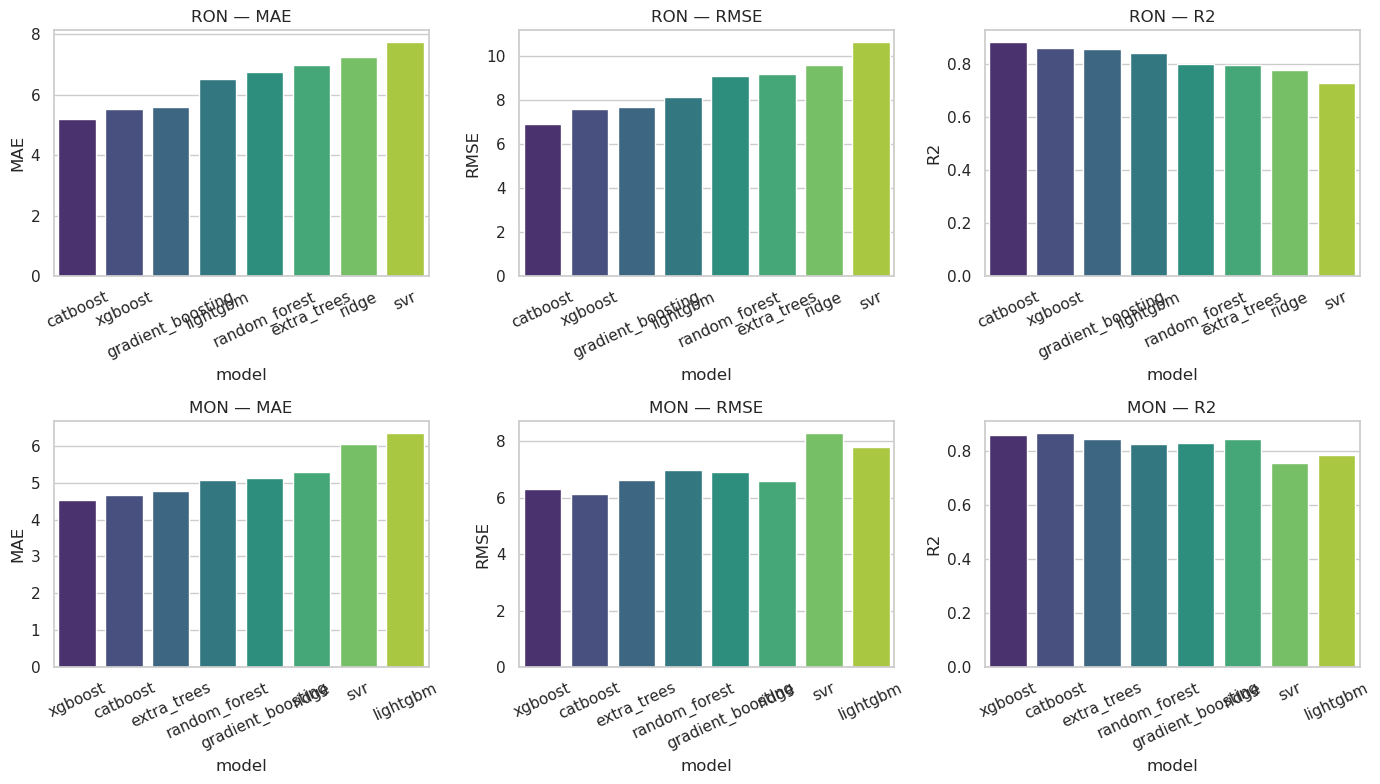

In [16]:
def metrics_table(results: dict) -> pd.DataFrame:
    rows = []
    for name, d in results.items():
        rows.append({"model": name, "MAE": d["MAE"], "RMSE": d["RMSE"], "R2": d["R2"]})
    return pd.DataFrame(rows).sort_values("MAE")


tab_ron = metrics_table(results_ron)
tab_mon = metrics_table(results_mon)
display(tab_ron)
display(tab_mon)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, (target, tab) in enumerate([("RON", tab_ron), ("MON", tab_mon)]):
    for j, metric in enumerate(["MAE", "RMSE", "R2"]):
        ax = axes[i, j]
        sns.barplot(data=tab, x="model", y=metric, ax=ax, palette="viridis")
        ax.set_title(f"{target} — {metric}")
        ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()


## 9. Ансамблирование лучших моделей

Три модели с наименьшим **MAE** на тесте объединяются в **VotingRegressor** (среднее предсказаний) и **StackingRegressor** с финальной **Ridge**.


--- RON ensembles ---
voting MAE 5.080655286611883 R2 0.881790914432264
stacking MAE 5.166009529591876 R2 0.8830206930616065
--- MON ensembles ---
voting MAE 4.378661266731747 R2 0.8750435860972933
stacking MAE 4.47893489520827 R2 0.8824378411512128


/tmp/ipykernel_3585332/1819539610.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tab_ron_all, x="model", y="MAE", ax=axes[0], palette="magma")
/tmp/ipykernel_3585332/1819539610.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tab_mon_all, x="model", y="MAE", ax=axes[1], palette="magma")


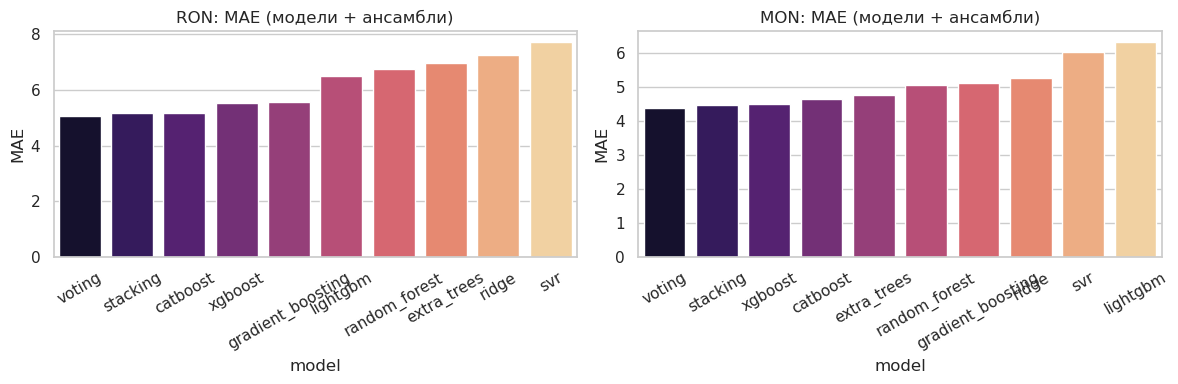

In [17]:
def top_k_pipes(results: dict, k: int = 3):
    names = metrics_table(results)["model"].tolist()[:k]
    return [(n, results[n]["pipe"]) for n in names]


def build_ensembles(results: dict, y_train: np.ndarray, y_test: np.ndarray, label: str):
    est_list = top_k_pipes(results, 3)

    vote = VotingRegressor(estimators=est_list)
    vote.fit(X_train_f, y_train)
    pred_v = vote.predict(X_test_f)

    stack = StackingRegressor(
        estimators=est_list,
        final_estimator=Ridge(alpha=1.0),
        passthrough=False,
        cv=5,
        n_jobs=-1,
    )
    stack.fit(X_train_f, y_train)
    pred_s = stack.predict(X_test_f)

    out = {
        "voting": {
            "pipe": vote,
            "MAE": mean_absolute_error(y_test, pred_v),
            "RMSE": root_mean_squared_error(y_test, pred_v),
            "R2": r2_score(y_test, pred_v),
        },
        "stacking": {
            "pipe": stack,
            "MAE": mean_absolute_error(y_test, pred_s),
            "RMSE": root_mean_squared_error(y_test, pred_s),
            "R2": r2_score(y_test, pred_s),
        },
    }
    print(f"--- {label} ensembles ---")
    for k, v in out.items():
        print(k, "MAE", v["MAE"], "R2", v["R2"])
    return out


ens_ron = build_ensembles(results_ron, y_ron_train, y_ron_test, "RON")
ens_mon = build_ensembles(results_mon, y_mon_train, y_mon_test, "MON")

for name, d in ens_ron.items():
    results_ron[name] = d
for name, d in ens_mon.items():
    results_mon[name] = d

tab_ron_all = metrics_table(results_ron)
tab_mon_all = metrics_table(results_mon)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=tab_ron_all, x="model", y="MAE", ax=axes[0], palette="magma")
axes[0].set_title("RON: MAE (модели + ансамбли)")
axes[0].tick_params(axis="x", rotation=30)
sns.barplot(data=tab_mon_all, x="model", y="MAE", ax=axes[1], palette="magma")
axes[1].set_title("MON: MAE (модели + ансамбли)")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


## 10. Лучшая модель: predicted vs true и остатки

По минимальному **MAE** на тесте (среди всех моделей и ансамблей) строим диагностические графики для **RON** и **MON** отдельно.


Лучшая по MAE (RON): voting


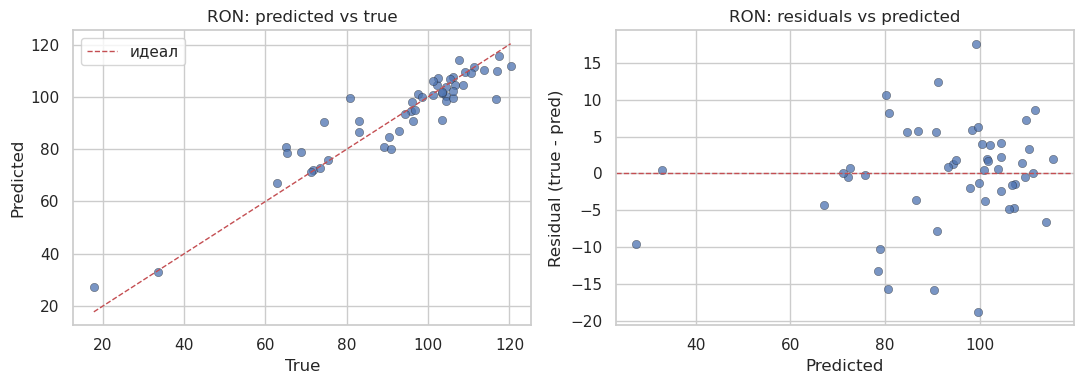

RON MAE=5.081 RMSE=7.018 R2=0.882
Лучшая по MAE (MON): voting


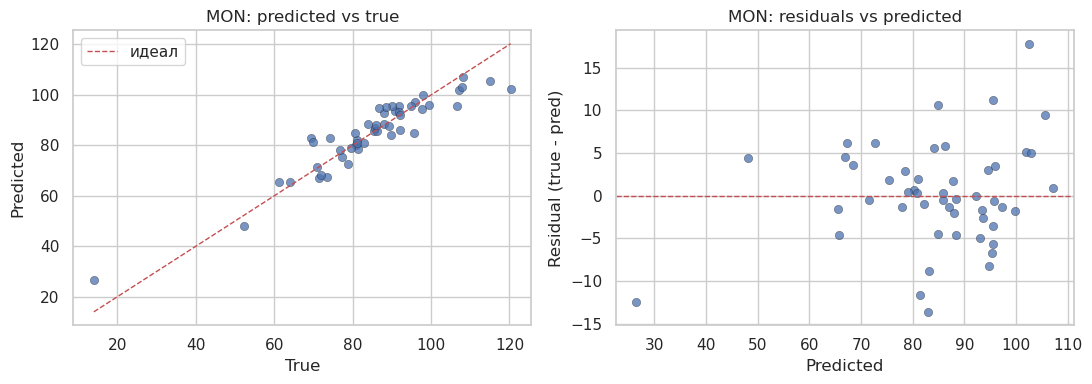

MON MAE=4.379 RMSE=5.922 R2=0.875


In [18]:
def pick_best(results: dict):
    tab = metrics_table(results)
    best_name = tab.iloc[0]["model"]
    return best_name, results[best_name]["pipe"]


def plot_diagnostics(pipe, y_true, target: str):
    pred = pipe.predict(X_test_f)
    resid = y_true - pred
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].scatter(y_true, pred, alpha=0.75, edgecolors="k", linewidths=0.3)
    lims = [min(y_true.min(), pred.min()), max(y_true.max(), pred.max())]
    axes[0].plot(lims, lims, "r--", lw=1, label="идеал")
    axes[0].set_xlabel("True")
    axes[0].set_ylabel("Predicted")
    axes[0].set_title(f"{target}: predicted vs true")
    axes[0].legend()
    axes[1].scatter(pred, resid, alpha=0.75, edgecolors="k", linewidths=0.3)
    axes[1].axhline(0, color="r", linestyle="--", lw=1)
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Residual (true - pred)")
    axes[1].set_title(f"{target}: residuals vs predicted")
    plt.tight_layout()
    plt.show()
    print(
        f"{target} MAE={mean_absolute_error(y_true, pred):.3f} "
        f"RMSE={root_mean_squared_error(y_true, pred):.3f} "
        f"R2={r2_score(y_true, pred):.3f}"
    )


best_ron_name, best_ron_pipe = pick_best(results_ron)
best_mon_name, best_mon_pipe = pick_best(results_mon)
print("Лучшая по MAE (RON):", best_ron_name)
plot_diagnostics(best_ron_pipe, y_ron_test, "RON")
print("Лучшая по MAE (MON):", best_mon_name)
plot_diagnostics(best_mon_pipe, y_mon_test, "MON")


## 11. Выводы по работе



### Подробные выводы

1. **Данные и таргеты**  
   Использовался файл `data.csv`: после удаления пропусков по **RON** и **MON** и фильтрации невалидных SMILES формируется матрица объектов. **RON** (Research Octane Number); **MON** (Motor Octane Number) — второй таргет.

2. **Признаки**  
   Признаки: **2D-дескрипторы** из `rdkit.Chem.Descriptors`, **Morgan fingerprint** (`rdFingerprintGenerator`) и **MACCS keys** (`rdMolDescriptors`).

3. **Отбор признаков и важность**  
   На обучении применены **VarianceThreshold**, удаление столбцов с попарной корреляцией |ρ| > 0.95, затем в каждом пайплайне — **SelectKBest(f_regression)** с числом признаков **K**, подобранным Optuna. Отдельный график сопоставляет топ-признаки по F-статистике и по `feature_importances_` RandomForest.

4. **Модели и Optuna**  
   Сравнивались **RandomForest**, **ExtraTrees**, **GradientBoosting** (sklearn), **XGBoost**, **LightGBM**, **CatBoost**, а также **Ridge** и **SVR**. Целевая функция Optuna — средний **MAE** по 5-fold CV на train.

5. **Сравнение на тесте**  
   Барплоты **MAE / RMSE / R²** показывают относительное качество моделей для **RON** и **MON**.
   На **RON** наименьшую **MAE** показал **CatBoost** — 5.18, на **MON** — **XGBoost** — 4.52.

6. **Ансамбли**  
   **VotingRegressor** усредняет три лучших по тестовому MAE базовых пайплайна; **StackingRegressor** с финальной **Ridge** учится комбинировать их предсказания. Итоговое сравнение по MAE см. в выводе ячейки ансамблей.
   Наилучшее значение метрики показал **VotingRegressor**: **RON** - 5.08, **MON** - 4.38.

7. **Диагностика лучшей модели**  
   **Predicted vs true** оценивает согласованность масштаба и выбросы; **остатки vs predicted** помогает увидеть систематические недоучёты и неравномерность дисперсии ошибок по диапазону предсказаний. В целом нет явной зависимости ошибки от величины таргета.
